<div align="center">

# Proyecto 1. Práctica de Algoritmos Heurísticos

### Diseño de portafolios y estrategias de trading con medias móviles optimizadas mediante algoritmos genéticos

**Instituto Tecnológico y de Estudios Superiores de Occidente (ITESO)**<br>
Departamento de Matemáticas y Física<br>
Métodos de Inteligencia Artificial

</div>

---

**Integrantes del equipo**

- Valeria Esmer Lobo

- Dayanni Godoy Rosales

- Estephany Lisset Herrera Placencia

- Maria Fernanda Vargas Vaca

<a id="indice"></a>
## Índice de contenidos

1. [Objetivo](#objetivo)
2. [Marco teórico](#marco-teorico)
   1. [Teoría moderna de portafolios (Markowitz)](#mt-markowitz)
   2. [Medidas de desempeño y de riesgo a la baja](#mt-riesgo)
   3. [Algoritmos genéticos](#mt-geneticos)
   4. [Trading con medias móviles: SMA y WMA](#mt-medias)
   5. [Validación fuera de muestra y sobreajuste](#mt-validacion)
3. [Datos, supuestos y configuración](#datos)
   1. [Supuestos del estudio](#datos-supuestos)
   2. [Librerías y parámetros](#datos-parametros)
   3. [Descarga de precios y cálculo de rendimientos](#datos-descarga)
   4. [División en periodos de entrenamiento y prueba](#datos-division)
4. [Fase 1: Portafolio de Markowitz](#fase-1)
   1. [Rendimiento, volatilidad e índice de Sharpe](#f1-funciones)
   2. [Semivarianza](#f1-semivarianza)
   3. [Algoritmo genético](#f1-genetico)
   4. [Portafolio de máximo Sharpe](#f1-sharpe)
   5. [Portafolio de mínima semivarianza](#f1-semivarianza-opt)
   6. [Composición y asignación del capital](#f1-asignacion)
   7. [Validación fuera de muestra](#f1-backtest)
   8. [Métricas de desempeño](#f1-metricas)
   9. [Gráficas de la Fase 1](#f1-graficas)
5. [Fase 2: Trading con media móvil simple (SMA)](#fase-2)
   1. [Planteamiento](#f2-planteamiento)
   2. [Simulación de la estrategia](#f2-simulacion)
   3. [Función de aptitud](#f2-aptitud)
   4. [Operadores del algoritmo genético](#f2-operadores)
   5. [Ejecución y resultados en entrenamiento](#f2-resultados)
   6. [Validación fuera de muestra](#f2-test)
6. [Fase 3: Trading con media móvil ponderada (WMA)](#fase-3)
   1. [Planteamiento](#f3-planteamiento)
   2. [Media móvil ponderada, restricción y función de aptitud](#f3-wma)
   3. [Algoritmo genético](#f3-genetico)
   4. [Ejecución de la optimización](#f3-ejecucion)
   5. [Verificación de la restricción de los pesos](#f3-restriccion)
   6. [Gráficas de la Fase 3](#f3-graficas)
   7. [Validación fuera de muestra: SMA frente a WMA](#f3-test)
   8. [Efecto de las comisiones](#f3-comisiones)
   9. [Discusión de la Fase 3](#f3-discusion)
7. [Comparativa y resultados destacados](#comparativa)
   1. [Tabla de resultados destacados](#comp-destacados)
   2. [Comparativa global en el periodo de prueba](#comp-global)
8. [Conclusiones](#conclusiones)
9. [Bibliografía](#bibliografia)

<a id="objetivo"></a>
## 1. Objetivo

Diseñar y comparar, mediante algoritmos genéticos, un portafolio de tres activos (MELI, REGN y B) basado en la teoría de Markowitz y dos estrategias de trading basadas en medias móviles (simple y ponderada), evaluando su desempeño fuera de muestra durante un año con una inversión inicial de $1,000,000.

[↑ Volver al índice](#indice)

<a id="marco-teorico"></a>
## 2. Marco teórico

<a id="mt-markowitz"></a>
### 2.1 Teoría moderna de portafolios (Markowitz)

Markowitz (1952) propuso seleccionar un portafolio considerando simultáneamente su rendimiento esperado y su riesgo, medido como la varianza de los rendimientos. Para un vector de ponderaciones $w$, un vector de rendimientos esperados $\mu$ y una matriz de covarianzas $\Sigma$:

$$R_p = w^\top \mu, \qquad \sigma_p = \sqrt{w^\top \Sigma \, w}, \qquad \sum_{i=1}^{3} w_i = 1, \quad w_i \ge 0$$

Al combinar activos con correlación imperfecta, el riesgo del portafolio es menor que el promedio ponderado de los riesgos individuales (diversificación). El conjunto de portafolios que ofrecen el máximo rendimiento para cada nivel de riesgo forma la **frontera eficiente**. En este trabajo, las ponderaciones se estiman con datos diarios y se anualizan multiplicando el rendimiento por 252 y la volatilidad por $\sqrt{252}$.

<a id="mt-riesgo"></a>
### 2.2 Medidas de desempeño y de riesgo a la baja

- **Índice de Sharpe** (Sharpe, 1966): rendimiento en exceso de la tasa libre de riesgo por unidad de volatilidad. Su máximo corresponde al portafolio tangente de la frontera eficiente.

$$Sharpe = \frac{R_p - R_f}{\sigma_p}$$

- **Semivarianza:** considera únicamente las desviaciones por debajo de un rendimiento mínimo aceptable (MAR). A diferencia de la varianza, no penaliza las variaciones favorables. Con $MAR = 0$:

$$SV = \frac{1}{T}\sum_{t=1}^{T} \min(r_{p,t},\, 0)^2$$

- **Índice de Sortino** (Sortino y van der Meer, 1991): cociente entre el rendimiento anualizado y la desviación a la baja $\sqrt{SV}$ anualizada.
- **Máxima caída (*max drawdown*):** mayor pérdida porcentual desde un máximo previo del valor del portafolio.

<a id="mt-geneticos"></a>
### 2.3 Algoritmos genéticos

Los algoritmos genéticos (Holland, 1975; Goldberg, 1989) son métodos heurísticos de búsqueda inspirados en la selección natural. Mantienen una población de soluciones candidatas (individuos o cromosomas) que evoluciona durante varias generaciones mediante:

1. **Evaluación:** cada individuo recibe un valor de aptitud (*fitness*) según la función objetivo.
2. **Selección:** los individuos más aptos tienen mayor probabilidad de reproducirse; aquí se usa selección por torneo de tres individuos.
3. **Cruce:** se combinan dos padres para generar un hijo; aquí se usa el cruce aritmético $hijo = \alpha \, padre_1 + (1-\alpha) \, padre_2$ con $\alpha \sim U(0,1)$.
4. **Mutación:** se introduce una perturbación aleatoria que mantiene la diversidad de la población.
5. **Elitismo:** los mejores individuos pasan intactos a la siguiente generación, por lo que la mejor aptitud nunca disminuye.

No requieren que la función objetivo sea continua ni derivable, lo que los hace adecuados para este proyecto: la aptitud de las estrategias de trading se obtiene mediante una simulación con señales discretas de compra y venta, y la Fase 3 involucra más de cien variables sujetas a una restricción de igualdad.

<a id="mt-medias"></a>
### 2.4 Trading con medias móviles: SMA y WMA

La media móvil suaviza la serie de precios para identificar su tendencia (Murphy, 1999). La regla de trading utilizada es la siguiente: si el precio cruza la media móvil hacia arriba, se compra; si la cruza hacia abajo, se vende y el capital permanece en efectivo.

- **Media móvil simple (SMA):** todos los periodos de la ventana de longitud $n$ tienen el mismo peso.

$$SMA_t = \frac{1}{n}\sum_{k=0}^{n-1} P_{t-k}$$

- **Media móvil ponderada (WMA):** cada periodo de la ventana recibe un peso propio.

$$WMA_t = \sum_{k=0}^{n-1} w_k \, P_{t-n+1+k}, \qquad w_k \ge 0, \qquad \sum_{k=0}^{n-1} w_k = 1$$

La SMA es el caso particular $w_k = 1/n$. La WMA lineal clásica asigna pesos proporcionales a $1, 2, \dots, n$, de modo que el precio más reciente es el de mayor peso.

<a id="mt-validacion"></a>
### 2.5 Validación fuera de muestra y sobreajuste

Los parámetros se optimizan con un periodo de **entrenamiento (TRAIN)** y se evalúan en un periodo posterior de **prueba (TEST)** que el algoritmo no utiliza. Esto permite detectar el **sobreajuste**: cuanto mayor es el número de parámetros ajustados con la misma cantidad de datos, más probable es que la solución capture ruido del pasado y no se sostenga en datos nuevos (Bailey et al., 2014). Para evitar el sesgo de anticipación (*look-ahead bias*), la posición de cada día se decide con la señal del día anterior.

[↑ Volver al índice](#indice)

<a id="datos"></a>
## 3. Datos, supuestos y configuración

<a id="datos-supuestos"></a>
### 3.1 Supuestos del estudio

| Elemento | Valor |
|---|---|
| Activos | MercadoLibre (MELI, comercio electrónico y servicios financieros), Regeneron Pharmaceuticals (REGN, biotecnología) y Barrick Mining Corporation (B, minería de oro y cobre) |
| Fuente de datos | Precios de cierre ajustados por dividendos y *splits* (Yahoo Finance, librería `yfinance`) |
| Periodo de entrenamiento (TRAIN) | 17 de septiembre de 2024 a 16 de septiembre de 2025 |
| Periodo de prueba (TEST) | 17 de septiembre de 2025 a 17 de septiembre de 2026 (un año de simulación) |
| Inversión inicial | $1,000,000 distribuidos entre los tres activos |
| Tasa libre de riesgo | 3.6% anual (referencia: bonos del Tesoro de EE. UU.) |
| Días bursátiles por año | 252 |
| Restricciones de ponderación | Sin ventas en corto ($w_i \ge 0$) y suma de ponderaciones igual a 100% |
| Costos de transacción | No se consideran en la optimización; su efecto se analiza en la sección 6.8 con una comisión de 0.25% por operación |

**Nota sobre la moneda:** los tres activos cotizan en dólares estadounidenses. La inversión inicial de $1,000,000 se simula aplicando los rendimientos en la moneda de cotización; no se modela el efecto del tipo de cambio.

<a id="datos-parametros"></a>
### 3.2 Librerías y parámetros

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display
from numpy.lib.stride_tricks import sliding_window_view

In [2]:
# Activos del portafolio
tickers = ["MELI", "REGN", "B"]

# Periodos de entrenamiento y prueba
train_start = "2024-09-17"
train_end = "2025-09-16"

test_start = "2025-09-17"
test_end = "2026-09-17"

# Inversión inicial
capital = 1_000_000

# Tasa libre de riesgo anual (bonos del Tesoro de EE. UU.)
rf = 0.036

# Días bursátiles por año
dias = 252

# Parámetros del algoritmo genético (comunes a las tres fases)
population_size = 100
generations = 200
mutation_rate = 0.20
elite_size = 5

# Semilla para que los resultados sean reproducibles
np.random.seed(42)


def formatear_tabla(df, porcentaje=(), moneda=(), decimales=()):
    """
    Devuelve una copia de la tabla con formato de presentación.
    Los datos originales no se modifican.
    """
    tabla = df.copy()
    for columna in porcentaje:
        tabla[columna] = (tabla[columna] * 100).map("{:.2f}%".format)
    for columna in moneda:
        tabla[columna] = tabla[columna].map("${:,.2f}".format)
    for columna in decimales:
        tabla[columna] = tabla[columna].map("{:.4f}".format)
    return tabla

<a id="datos-descarga"></a>
### 3.3 Descarga de precios y cálculo de rendimientos

Se descargan los precios de cierre ajustados y se calculan los rendimientos simples diarios con `pct_change()`. Los precios se guardan en un archivo CSV para que las ejecuciones posteriores utilicen exactamente los mismos datos, ya que Yahoo Finance recalcula los precios ajustados cuando un activo paga dividendos.

In [3]:
# yfinance no incluye la fecha "end", por lo que se descarga un día adicional
end_download = "2026-09-18"

archivo_precios = f"precios_{'_'.join(tickers)}.csv"

if os.path.exists(archivo_precios):
    prices = pd.read_csv(
        archivo_precios,
        index_col=0,
        parse_dates=True,
        float_precision="round_trip"
    )
else:
    data = yf.download(
        tickers,
        start=train_start,
        end=end_download,
        auto_adjust=True,
        progress=False
    )
    # Precios de cierre ajustados, en el orden de la lista de activos
    prices = data["Close"][tickers].dropna()
    prices.to_csv(archivo_precios)

# Rendimientos simples diarios
returns = prices.pct_change().dropna()

returns.head()

Ticker,MELI,REGN,B
Date,,,
2024-09-18,0.013682,-0.006924,-0.020508
2024-09-19,0.003215,0.009993,0.008475
2024-09-20,-0.002678,-0.004486,0.007414
2024-09-23,-0.000532,-0.046331,-0.008342
2024-09-24,0.003981,-0.042125,0.010886


<a id="datos-division"></a>
### 3.4 División en periodos de entrenamiento y prueba

El periodo **TRAIN** se utiliza para encontrar las ponderaciones y los parámetros de cada estrategia. El periodo **TEST** permite evaluar qué habría ocurrido después, aplicando esas mismas ponderaciones a datos que el algoritmo no utilizó.

In [4]:
train = returns.loc[train_start:train_end]
test = returns.loc[test_start:test_end]

print(f"Observaciones TRAIN: {len(train)} ({train.index.min():%d/%m/%Y} a {train.index.max():%d/%m/%Y})")
print(f"Observaciones TEST:  {len(test)} ({test.index.min():%d/%m/%Y} a {test.index.max():%d/%m/%Y})")

Observaciones TRAIN: 249 (18/09/2024 a 16/09/2025)
Observaciones TEST:  252 (17/09/2025 a 17/09/2026)


<a id="fase-1"></a>
## 4. Fase 1: Portafolio de Markowitz

Se buscan las ponderaciones de los tres activos con un algoritmo genético bajo dos criterios: máximo índice de Sharpe y mínima semivarianza. Como referencia se incluye el portafolio equiponderado.

<a id="f1-funciones"></a>
### 4.1 Rendimiento, volatilidad e índice de Sharpe

Las medias y covarianzas se estiman únicamente con el periodo TRAIN. Las funciones implementan las expresiones de la sección 2.1, anualizadas:

$$R_p = 252 \cdot w^\top \mu, \qquad \sigma_p = \sqrt{252} \cdot \sqrt{w^\top \Sigma \, w}, \qquad Sharpe = \frac{R_p - R_f}{\sigma_p}$$

In [5]:
mean_returns = train.mean()
cov_matrix = train.cov()


def portfolio_return(weights):
    """Rendimiento esperado anualizado del portafolio."""
    return np.dot(weights, mean_returns) * dias


def portfolio_volatility(weights):
    """Volatilidad anualizada del portafolio."""
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    return np.sqrt(variance) * np.sqrt(dias)


def sharpe_ratio(weights):
    """Índice de Sharpe anualizado del portafolio."""
    return (portfolio_return(weights) - rf) / portfolio_volatility(weights)

<a id="f1-semivarianza"></a>
### 4.2 Semivarianza

Se calculan los rendimientos diarios del portafolio y se conservan únicamente las desviaciones por debajo del rendimiento mínimo aceptable, que en este caso es $MAR = 0$.

In [6]:
def semivariance(weights):
    """Semivarianza diaria del portafolio con rendimiento mínimo aceptable igual a 0."""
    portfolio_returns = np.dot(train, weights)
    downside = np.minimum(portfolio_returns, 0)
    return np.mean(downside ** 2)

<a id="f1-genetico"></a>
### 4.3 Algoritmo genético

Cada individuo es un portafolio, representado por un vector de tres ponderaciones no negativas que suman 1. Los operadores son:

- **Población inicial:** ponderaciones aleatorias normalizadas.
- **Selección:** torneo entre tres portafolios elegidos al azar; se reproduce el de mayor aptitud.
- **Cruce:** aritmético; una combinación convexa de dos vectores que suman 1 también suma 1.
- **Mutación:** con probabilidad de 20% se suma ruido gaussiano ($\sigma = 0.05$), se recortan los valores negativos y se normaliza de nuevo.
- **Elitismo:** los cinco mejores portafolios pasan directamente a la siguiente generación.

La función `algoritmo_genetico` recibe como argumento la función de aptitud a maximizar, lo que permite reutilizarla para los dos criterios de optimización.

In [7]:
def crear_poblacion():
    """Genera la población inicial de portafolios con ponderaciones que suman 1."""
    poblacion = []
    for i in range(population_size):
        weights = np.random.random(3)
        weights = weights / weights.sum()
        poblacion.append(weights)
    return np.array(poblacion)


def seleccionar(poblacion, fitness):
    """Selección por torneo: de tres individuos al azar se elige el de mayor aptitud."""
    candidatos = np.random.choice(len(poblacion), 3, replace=False)
    mejor = candidatos[np.argmax(fitness[candidatos])]
    return poblacion[mejor]


def crossover(padre1, padre2):
    """Cruce aritmético entre dos portafolios."""
    alpha = np.random.random()
    return alpha * padre1 + (1 - alpha) * padre2


def mutacion(weights):
    """Mutación gaussiana que conserva ponderaciones no negativas y con suma igual a 1."""
    if np.random.random() < mutation_rate:
        cambio = np.random.normal(0, 0.05, 3)
        weights = weights + cambio
        weights = np.clip(weights, 0, 1)
        weights = weights / weights.sum()
    return weights


def algoritmo_genetico(fitness_function):
    """
    Maximiza la función de aptitud recibida.
    Devuelve el mejor portafolio y el historial de la mejor aptitud por generación.
    """
    poblacion = crear_poblacion()
    history = []

    for generation in range(generations):
        fitness = np.array([fitness_function(weights) for weights in poblacion])

        # Ordenar de mayor a menor aptitud
        orden = np.argsort(fitness)[::-1]
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        history.append(fitness[0])

        # Elitismo
        nueva_poblacion = list(poblacion[:elite_size])

        # Reproducción
        while len(nueva_poblacion) < population_size:
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            hijo = crossover(padre1, padre2)
            hijo = mutacion(hijo)
            nueva_poblacion.append(hijo)

        poblacion = np.array(nueva_poblacion)

    # Evaluación final de la última generación
    fitness = np.array([fitness_function(weights) for weights in poblacion])
    mejor = poblacion[np.argmax(fitness)]

    return mejor, history

<a id="f1-sharpe"></a>
### 4.4 Portafolio de máximo Sharpe

La función de aptitud es directamente el índice de Sharpe del portafolio en el periodo TRAIN.

In [8]:
weights_sharpe, history_sharpe = algoritmo_genetico(sharpe_ratio)

print(f"Índice de Sharpe (TRAIN): {sharpe_ratio(weights_sharpe):.4f}\n")
print("Ponderaciones del portafolio de máximo Sharpe:")
for ticker, weight in zip(tickers, weights_sharpe):
    print(f"  {ticker:<5}{weight * 100:>8.2f}%")

Índice de Sharpe (TRAIN): 1.2246

Ponderaciones del portafolio de máximo Sharpe:
  MELI    21.49%
  REGN     0.00%
  B       78.51%


<a id="f1-semivarianza-opt"></a>
### 4.5 Portafolio de mínima semivarianza

Minimizar únicamente el riesgo puede conducir a un portafolio con rendimiento muy bajo. Por ello se agrega una restricción: el rendimiento esperado debe ser al menos igual al del portafolio **equiponderado**. Los portafolios que no la cumplen reciben una aptitud de −1000, y como el algoritmo maximiza, la aptitud de los portafolios factibles es el negativo de la semivarianza.

In [9]:
equal_weights = np.array([1/3, 1/3, 1/3])

# Rendimiento mínimo exigido: el del portafolio equiponderado
target_return = portfolio_return(equal_weights)
print(f"Rendimiento mínimo exigido (anualizado): {target_return * 100:.4f}%\n")


def fitness_semivariance(weights):
    """Aptitud: negativo de la semivarianza, con penalización si no se alcanza el rendimiento mínimo."""
    if portfolio_return(weights) < target_return:
        return -1000
    return -semivariance(weights)


weights_semi, history_semi = algoritmo_genetico(fitness_semivariance)

print("Ponderaciones del portafolio de mínima semivarianza:")
for ticker, weight in zip(tickers, weights_semi):
    print(f"  {ticker:<5}{weight * 100:>8.2f}%")

Rendimiento mínimo exigido (anualizado): 0.8602%

Ponderaciones del portafolio de mínima semivarianza:
  MELI    29.75%
  REGN    20.98%
  B       49.28%


<a id="f1-asignacion"></a>
### 4.6 Composición y asignación del capital

Se comparan tres portafolios: **máximo Sharpe**, **mínima semivarianza** y **equiponderado**. La tabla muestra la ponderación de cada activo y el monto asignado de la inversión inicial.

In [10]:
portfolios = {
    "Máximo Sharpe": weights_sharpe,
    "Mínima Semivarianza": weights_semi,
    "Equiponderado": equal_weights
}

filas = []
for name, weights in portfolios.items():
    for ticker, weight in zip(tickers, weights):
        filas.append({
            "Portafolio": name,
            "Activo": ticker,
            "Ponderación": weight,
            "Monto asignado": weight * capital
        })

asignacion_fase1 = pd.DataFrame(filas)
display(formatear_tabla(asignacion_fase1, porcentaje=["Ponderación"], moneda=["Monto asignado"]))

,Portafolio,Activo,Ponderación,Monto asignado
0,Máximo Sharpe,MELI,21.49%,"$214,947.13"
1,Máximo Sharpe,REGN,0.00%,$0.00
2,Máximo Sharpe,B,78.51%,"$785,052.87"
3,Mínima Semivarianza,MELI,29.75%,"$297,481.72"
4,Mínima Semivarianza,REGN,20.98%,"$209,762.53"
5,Mínima Semivarianza,B,49.28%,"$492,755.76"
6,Equiponderado,MELI,33.33%,"$333,333.33"
7,Equiponderado,REGN,33.33%,"$333,333.33"
8,Equiponderado,B,33.33%,"$333,333.33"


<a id="f1-backtest"></a>
### 4.7 Validación fuera de muestra

Se aplica el periodo TEST, que no se utilizó durante la optimización, y se simula la evolución de la inversión inicial manteniendo fijas las ponderaciones (estrategia de comprar y mantener).

In [11]:
portfolio_test_returns = pd.DataFrame(index=test.index)

for name, weights in portfolios.items():
    portfolio_test_returns[name] = np.dot(test, weights)

# Evolución de la inversión inicial en el periodo TEST
portfolio_values = capital * (1 + portfolio_test_returns).cumprod()

portfolio_values.tail()

,Máximo Sharpe,Mínima Semivarianza,Equiponderado
Date,,,
2026-09-11,1.381494e+06,1.299870e+06,1.251730e+06
2026-09-14,1.350906e+06,1.286399e+06,1.246961e+06
2026-09-15,1.346760e+06,1.269401e+06,1.223730e+06
2026-09-16,1.344750e+06,1.269599e+06,1.224963e+06
2026-09-17,1.370756e+06,1.288485e+06,1.240507e+06


<a id="f1-metricas"></a>
### 4.8 Métricas de desempeño

La función `metricas` calcula el rendimiento acumulado, el rendimiento y la volatilidad anualizados, los índices de Sharpe y de Sortino, la desviación a la baja y la máxima caída. Se utiliza $MAR = 0$, es decir, cualquier día con rendimiento negativo se considera desfavorable. Esta misma función se reutiliza en las fases 2 y 3.

In [12]:
def metricas(returns):
    """Métricas de desempeño a partir de una serie de rendimientos diarios."""
    cumulative_return = (1 + returns).prod() - 1
    annual_return = returns.mean() * dias
    volatility = returns.std() * np.sqrt(dias)
    sharpe = (annual_return - rf) / volatility

    # Desviación a la baja anualizada (MAR = 0)
    downside_returns = np.minimum(returns, 0)
    downside_deviation = np.sqrt(np.mean(downside_returns ** 2)) * np.sqrt(dias)
    sortino = annual_return / downside_deviation

    # Máxima caída desde un máximo previo
    wealth = (1 + returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "Rendimiento": cumulative_return,
        "Rendimiento anual": annual_return,
        "Volatilidad": volatility,
        "Sharpe": sharpe,
        "Downside": downside_deviation,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown
    }

In [13]:
filas = []
for name, weights in portfolios.items():
    final_value = portfolio_values[name].iloc[-1]
    filas.append({
        "Estrategia": name,
        **metricas(portfolio_test_returns[name]),
        "Capital final": final_value,
        "Ganancia": final_value - capital
    })

resultados = pd.DataFrame(filas)

display(formatear_tabla(
    resultados,
    porcentaje=["Rendimiento", "Rendimiento anual", "Volatilidad", "Downside", "Max Drawdown"],
    moneda=["Capital final", "Ganancia"],
    decimales=["Sharpe", "Sortino"]
).rename(columns={
    "Rendimiento": "Rend. acumulado",
    "Rendimiento anual": "Rend. anualizado",
    "Downside": "Desviación a la baja",
    "Max Drawdown": "Máxima caída"
}))

,Estrategia,Rend. acumulado,Rend. anualizado,Volatilidad,Sharpe,Desviación a la baja,Sortino,Máxima caída,Capital final,Ganancia
0,Máximo Sharpe,37.08%,39.72%,40.41%,0.8939,28.19%,1.4093,-29.57%,"$1,370,756.49","$370,756.49"
1,Mínima Semivarianza,28.85%,29.89%,30.16%,0.8718,20.47%,1.4599,-26.06%,"$1,288,485.48","$288,485.48"
2,Equiponderado,24.05%,25.04%,26.46%,0.8103,17.60%,1.4225,-25.41%,"$1,240,507.14","$240,507.14"


<a id="f1-graficas"></a>
### 4.9 Gráficas de la Fase 1

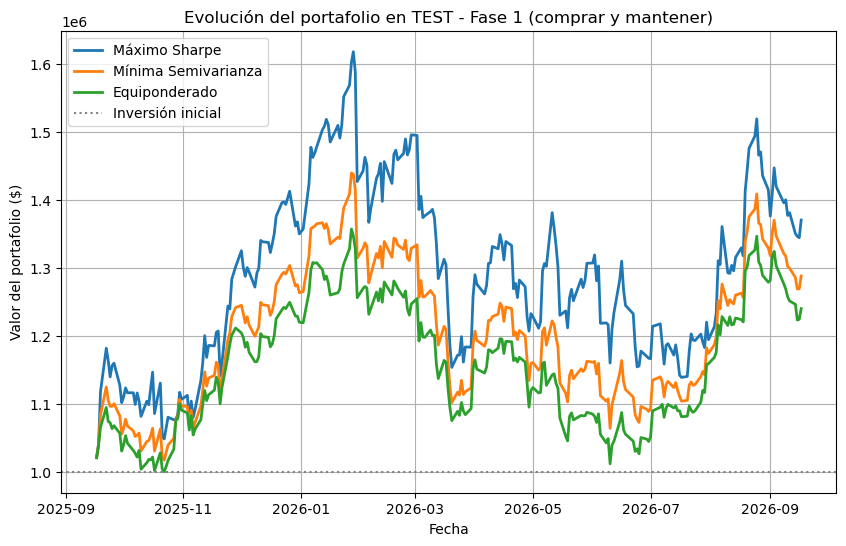

In [14]:
plt.figure(figsize=(10, 6))

for name in portfolio_values.columns:
    plt.plot(portfolio_values.index, portfolio_values[name], linewidth=2, label=name)

plt.axhline(capital, color="gray", linestyle=":", label="Inversión inicial")
plt.title("Evolución del portafolio en TEST - Fase 1 (comprar y mantener)")
plt.xlabel("Fecha")
plt.ylabel("Valor del portafolio ($)")
plt.legend()
plt.grid(True)
plt.show()

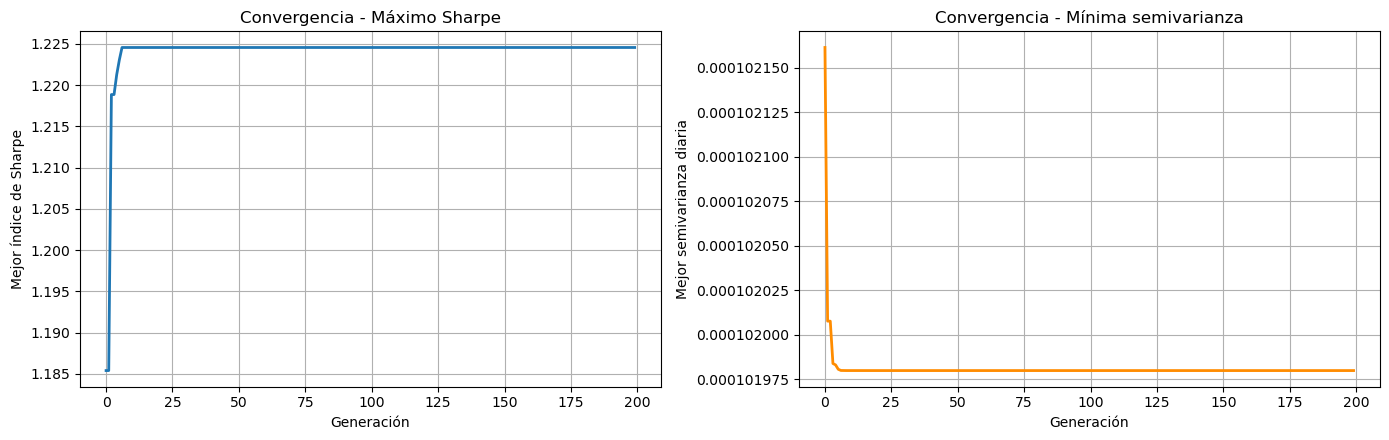

In [15]:
fig, (eje_sharpe, eje_semi) = plt.subplots(1, 2, figsize=(14, 4.5))

eje_sharpe.plot(history_sharpe, linewidth=2)
eje_sharpe.set_title("Convergencia - Máximo Sharpe")
eje_sharpe.set_xlabel("Generación")
eje_sharpe.set_ylabel("Mejor índice de Sharpe")
eje_sharpe.grid(True)

# La aptitud es el negativo de la semivarianza; se grafica la semivarianza
eje_semi.plot(-np.array(history_semi), linewidth=2, color="darkorange")
eje_semi.set_title("Convergencia - Mínima semivarianza")
eje_semi.set_xlabel("Generación")
eje_semi.set_ylabel("Mejor semivarianza diaria")
eje_semi.grid(True)

plt.tight_layout()
plt.show()

[↑ Volver al índice](#indice)

<a id="fase-2"></a>
## 5. Fase 2: Trading con media móvil simple (SMA)

<a id="f2-planteamiento"></a>
### 5.1 Planteamiento

Se aplica a cada activo la regla de cruce del precio con su media móvil simple. Siguiendo la alternativa que plantean los lineamientos del proyecto, el algoritmo genético determina simultáneamente un **nuevo capital inicial** para cada activo y la **ventana óptima** de su media móvil. El cromosoma tiene seis genes:

$$[\, w_{MELI},\ w_{REGN},\ w_{B},\ n_{MELI},\ n_{REGN},\ n_{B} \,]$$

donde las ponderaciones $w$ son continuas, no negativas y suman 1, y las ventanas $n$ son enteras entre 5 y 200 días. La optimización utiliza únicamente los precios del periodo TRAIN.

In [16]:
# Precios del periodo de entrenamiento
train_prices = prices.loc[train_start:train_end]

# Límites de la ventana de la media móvil (días)
MIN_WINDOW = 5
MAX_WINDOW = 200

<a id="f2-simulacion"></a>
### 5.2 Simulación de la estrategia

La función `simular_trading_sma` detecta los cruces del precio con la SMA y construye la posición diaria (1 = invertido, 0 = en efectivo). La posición se mantiene hasta la siguiente señal y se aplica con un día de retraso para evitar el sesgo de anticipación. La función `calcular_rendimiento_trading` combina las estrategias de los tres activos según su ponderación.

In [17]:
def simular_trading_sma(precios, ventana):
    """
    Simula la estrategia de cruce del precio con una media móvil simple (SMA).

    Compra cuando el precio cruza la SMA hacia arriba y vende cuando la cruza
    hacia abajo. Se utiliza la posición del día anterior para evitar el sesgo
    de anticipación (look-ahead bias).
    """
    ventana = int(np.clip(ventana, MIN_WINDOW, MAX_WINDOW))
    sma = precios.rolling(window=ventana).mean()

    # Cruce positivo: el precio pasa de estar por debajo a estar por encima de la SMA
    cruce_compra = (precios > sma) & (precios.shift(1) <= sma.shift(1))

    # Cruce negativo: el precio pasa de estar por encima a estar por debajo de la SMA
    cruce_venta = (precios < sma) & (precios.shift(1) >= sma.shift(1))

    # Posición: 1 tras un cruce de compra y 0 tras un cruce de venta.
    # ffill() mantiene la última señal; antes de la primera señal no hay posición.
    posiciones = pd.Series(np.nan, index=precios.index)
    posiciones.loc[cruce_compra] = 1
    posiciones.loc[cruce_venta] = 0
    posiciones = posiciones.ffill().fillna(0)

    retornos_diarios = precios.pct_change()
    retornos_estrategia = posiciones.shift(1) * retornos_diarios

    return retornos_estrategia.fillna(0)


def calcular_rendimiento_trading(pesos, ventanas):
    """Rendimientos diarios del portafolio en TRAIN con una SMA por activo."""
    retornos_portafolio = pd.Series(0.0, index=train_prices.index)

    for i, ticker in enumerate(tickers):
        retornos_activo = simular_trading_sma(train_prices[ticker], ventanas[i])
        retornos_portafolio += retornos_activo * pesos[i]

    return retornos_portafolio

<a id="f2-aptitud"></a>
### 5.3 Función de aptitud

De acuerdo con los lineamientos, se toman como parámetros el rendimiento promedio y el riesgo promedio del balance, ambos anualizados. Se combinan en el índice de Sharpe para favorecer las estrategias con mayor rendimiento por unidad de riesgo. Las estrategias sin variación (sin operaciones) reciben una aptitud de −1000.

In [18]:
def fitness_trading(cromosoma):
    """
    Aptitud de un individuo de la Fase 2.

    Cromosoma: [peso_1, peso_2, peso_3, ventana_1, ventana_2, ventana_3]
    """
    pesos = np.array(cromosoma[:3], dtype=float)
    if pesos.sum() <= 0:
        return -1000
    pesos = pesos / pesos.sum()

    ventanas = np.clip(np.array(cromosoma[3:], dtype=int), MIN_WINDOW, MAX_WINDOW)

    retornos_portafolio = calcular_rendimiento_trading(pesos, ventanas)

    rendimiento_promedio = retornos_portafolio.mean() * dias
    riesgo_promedio = retornos_portafolio.std() * np.sqrt(dias)

    if riesgo_promedio <= 0:
        return -1000

    return (rendimiento_promedio - rf) / riesgo_promedio

<a id="f2-operadores"></a>
### 5.4 Operadores del algoritmo genético

- **Población inicial:** ponderaciones aleatorias normalizadas y ventanas enteras aleatorias entre 5 y 200 días.
- **Cruce:** aritmético para las ponderaciones (se normalizan después) y uniforme para las ventanas (cada ventana se hereda de uno de los dos padres con probabilidad de 50%).
- **Mutación:** con probabilidad de 20%, ruido gaussiano ($\sigma = 0.05$) en las ponderaciones y un cambio entero de −10 a +10 días en las ventanas, respetando los límites.
- **Selección y elitismo:** los mismos de la Fase 1.

In [19]:
def crear_poblacion_fase2():
    """Población inicial: tres ponderaciones que suman 1 seguidas de tres ventanas enteras."""
    poblacion = []

    for _ in range(population_size):
        pesos = np.random.random(3)
        pesos = pesos / pesos.sum()
        ventanas = np.random.randint(MIN_WINDOW, MAX_WINDOW + 1, 3)
        poblacion.append(np.concatenate((pesos, ventanas)))

    return np.array(poblacion)


def mutacion_fase2(cromosoma):
    """Mutación de ponderaciones (ruido gaussiano) y de ventanas (desplazamiento entero)."""
    if np.random.random() < mutation_rate:
        # Ponderaciones: no negativas y con suma igual a 1
        cambio_pesos = np.random.normal(0, 0.05, 3)
        pesos = np.clip(cromosoma[:3] + cambio_pesos, 0, 1)
        if pesos.sum() == 0:
            pesos = np.ones(3)
        pesos = pesos / pesos.sum()

        # Ventanas: dentro de los límites permitidos
        cambio_ventanas = np.random.randint(-10, 11, 3)
        ventanas = np.clip(cromosoma[3:] + cambio_ventanas, MIN_WINDOW, MAX_WINDOW)

        cromosoma = np.concatenate((pesos, ventanas))

    return cromosoma


def crossover_fase2(padre1, padre2):
    """Cruce aritmético para las ponderaciones y uniforme para las ventanas."""
    hijo = np.zeros(6)

    alpha = np.random.random()
    hijo[:3] = alpha * padre1[:3] + (1 - alpha) * padre2[:3]
    hijo[:3] = hijo[:3] / hijo[:3].sum()

    for i in range(3, 6):
        hijo[i] = padre1[i] if np.random.random() < 0.5 else padre2[i]

    return hijo


def algoritmo_genetico_fase2():
    """Optimiza simultáneamente las ponderaciones del capital y las ventanas de la SMA."""
    poblacion = crear_poblacion_fase2()
    history = []

    for generation in range(generations):
        fitness = np.array([fitness_trading(individuo) for individuo in poblacion])

        orden = np.argsort(fitness)[::-1]
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        history.append(fitness[0])

        nueva_poblacion = list(poblacion[:elite_size])

        while len(nueva_poblacion) < population_size:
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            hijo = crossover_fase2(padre1, padre2)
            hijo = mutacion_fase2(hijo)
            nueva_poblacion.append(hijo)

        poblacion = np.array(nueva_poblacion)

    fitness_final = np.array([fitness_trading(individuo) for individuo in poblacion])
    mejor_individuo = poblacion[np.argmax(fitness_final)]

    return mejor_individuo, history

<a id="f2-resultados"></a>
### 5.5 Ejecución y resultados en entrenamiento

In [20]:
mejor_cromosoma_f2, history_f2 = algoritmo_genetico_fase2()

# Ponderaciones del capital y ventanas óptimas
pesos_optimos = mejor_cromosoma_f2[:3] / mejor_cromosoma_f2[:3].sum()
ventanas_optimas = mejor_cromosoma_f2[3:].astype(int)

# Desempeño en TRAIN
retornos_optimos = calcular_rendimiento_trading(pesos_optimos, ventanas_optimas)
rendimiento_optimo = retornos_optimos.mean() * dias
riesgo_optimo = retornos_optimos.std() * np.sqrt(dias)
sharpe_optimo = (rendimiento_optimo - rf) / riesgo_optimo

print("Resultados de la Fase 2 (TRAIN)")
print("-" * 40)
print(f"Rendimiento promedio anualizado: {rendimiento_optimo * 100:.2f}%")
print(f"Riesgo promedio anualizado:      {riesgo_optimo * 100:.2f}%")
print(f"Índice de Sharpe:                {sharpe_optimo:.4f}")

tabla_resultados = pd.DataFrame({
    "Activo": tickers,
    "Ponderación": pesos_optimos,
    "Capital inicial": pesos_optimos * capital,
    "Ventana SMA (días)": ventanas_optimas
})

display(formatear_tabla(tabla_resultados, porcentaje=["Ponderación"], moneda=["Capital inicial"]))

Resultados de la Fase 2 (TRAIN)
----------------------------------------
Rendimiento promedio anualizado: 45.45%
Riesgo promedio anualizado:      14.37%
Índice de Sharpe:                2.9127


,Activo,Ponderación,Capital inicial,Ventana SMA (días)
0,MELI,14.53%,"$145,298.87",54
1,REGN,0.00%,$0.03,162
2,B,85.47%,"$854,701.10",106


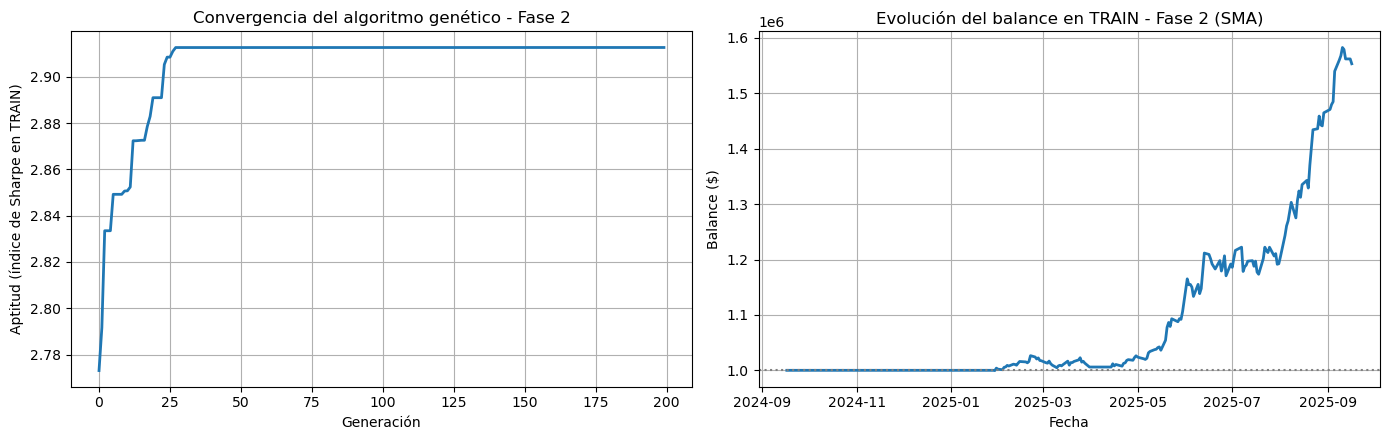

In [21]:
fig, (eje_fit, eje_bal) = plt.subplots(1, 2, figsize=(14, 4.5))

eje_fit.plot(history_f2, linewidth=2)
eje_fit.set_title("Convergencia del algoritmo genético - Fase 2")
eje_fit.set_xlabel("Generación")
eje_fit.set_ylabel("Aptitud (índice de Sharpe en TRAIN)")
eje_fit.grid(True)

balance = (1 + retornos_optimos).cumprod()
eje_bal.plot(balance * capital, linewidth=2)
eje_bal.axhline(capital, color="gray", linestyle=":")
eje_bal.set_title("Evolución del balance en TRAIN - Fase 2 (SMA)")
eje_bal.set_xlabel("Fecha")
eje_bal.set_ylabel("Balance ($)")
eje_bal.grid(True)

plt.tight_layout()
plt.show()

<a id="f2-test"></a>
### 5.6 Validación fuera de muestra

Para el periodo TEST se utiliza la serie completa de precios (TRAIN y TEST). De esta forma, la media móvil ya cuenta con historial suficiente al comenzar la prueba y no se pierden las primeras señales por falta de datos.

In [22]:
def calcular_rendimiento_trading_completo(pesos, ventanas):
    """Igual que calcular_rendimiento_trading, pero con la serie completa de precios."""
    retornos_portafolio = pd.Series(0.0, index=prices.index)

    for i, ticker in enumerate(tickers):
        retornos_activo = simular_trading_sma(prices[ticker], ventanas[i])
        retornos_portafolio += retornos_activo * pesos[i]

    return retornos_portafolio


retornos_completos_f2 = calcular_rendimiento_trading_completo(pesos_optimos, ventanas_optimas)
retornos_test_f2 = retornos_completos_f2.loc[test_start:test_end]

rendimiento_test_f2 = retornos_test_f2.mean() * dias
riesgo_test_f2 = retornos_test_f2.std() * np.sqrt(dias)
sharpe_test_f2 = (rendimiento_test_f2 - rf) / riesgo_test_f2

valor_final_train_f2 = capital * (1 + retornos_optimos).prod()
valor_final_test_f2 = capital * (1 + retornos_test_f2).prod()

print(f"Observaciones en TEST: {len(retornos_test_f2)}\n")

comparacion_f2 = pd.DataFrame({
    "Métrica": ["Rendimiento anualizado", "Riesgo anualizado", "Índice de Sharpe", "Capital final"],
    "TRAIN": [
        f"{rendimiento_optimo * 100:.2f}%",
        f"{riesgo_optimo * 100:.2f}%",
        f"{sharpe_optimo:.4f}",
        f"${valor_final_train_f2:,.2f}"
    ],
    "TEST": [
        f"{rendimiento_test_f2 * 100:.2f}%",
        f"{riesgo_test_f2 * 100:.2f}%",
        f"{sharpe_test_f2:.4f}",
        f"${valor_final_test_f2:,.2f}"
    ]
})

display(comparacion_f2)

Observaciones en TEST: 252



,Métrica,TRAIN,TEST
0,Rendimiento anualizado,45.45%,29.84%
1,Riesgo anualizado,14.37%,33.87%
2,Índice de Sharpe,2.9127,0.7748
3,Capital final,"$1,553,358.80","$1,272,164.07"


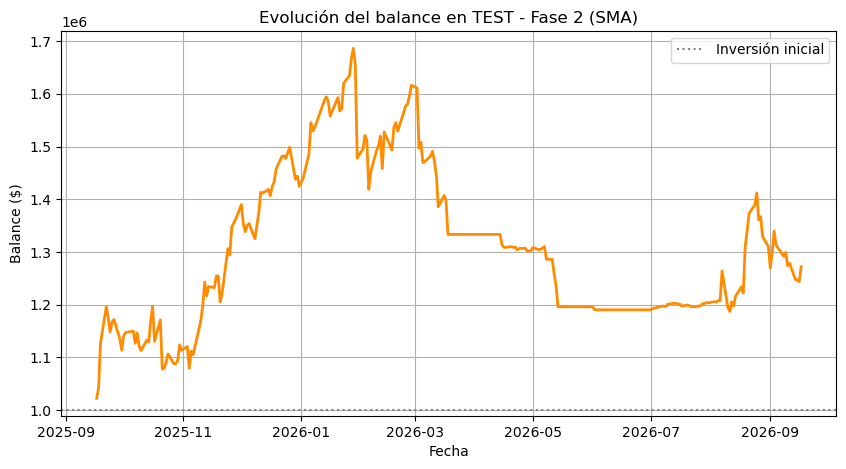

In [23]:
balance_test_f2 = (1 + retornos_test_f2).cumprod() * capital

plt.figure(figsize=(10, 5))
plt.plot(balance_test_f2, linewidth=2, color="darkorange")
plt.axhline(capital, color="gray", linestyle=":", label="Inversión inicial")
plt.title("Evolución del balance en TEST - Fase 2 (SMA)")
plt.xlabel("Fecha")
plt.ylabel("Balance ($)")
plt.legend()
plt.grid(True)
plt.show()

[↑ Volver al índice](#indice)

<a id="fase-3"></a>
## 6. Fase 3: Trading con media móvil ponderada (WMA)

<a id="f3-planteamiento"></a>
### 6.1 Planteamiento

Se busca mejorar la estrategia de la Fase 2 sustituyendo la SMA por una WMA en la que cada periodo de la ventana recibe un peso propio:

$$WMA_t = \sum_{k=0}^{n-1} w_k \, P_{t-n+1+k}, \qquad w_k \ge 0, \qquad \sum_{k=0}^{n-1} w_k = 1$$

- $w_{n-1}$ pondera el precio más reciente y $w_0$ el más antiguo de la ventana.
- Si $w_k = 1/n$ para todo $k$, se obtiene exactamente la SMA de la Fase 2; por lo tanto, el espacio de búsqueda contiene la solución anterior.
- Se conservan de la Fase 2 el capital asignado a cada activo y la longitud $n$ de cada ventana; únicamente se optimizan los pesos $w_k$.
- Los activos que recibieron un capital prácticamente nulo en la Fase 2 no influyen en el resultado, por lo que conservan pesos iguales (SMA) y no se incluyen en el cromosoma.

<a id="f3-wma"></a>
### 6.2 Media móvil ponderada, restricción y función de aptitud

La restricción $\sum w_k = 1$ con $w_k \ge 0$ se garantiza mediante la función `reparar_pesos`, que proyecta cualquier vector al conjunto factible: recorta los valores negativos, normaliza y absorbe el residuo de redondeo de punto flotante en el peso más grande. La función de aptitud es la misma de la Fase 2 (índice de Sharpe en TRAIN), para que la comparación entre ambas fases sea justa.

In [24]:
# Longitud de la ventana de cada activo, obtenida en la Fase 2
longitudes = [int(v) for v in ventanas_optimas]

# Solo se optimizan los activos con capital asignado
UMBRAL_CAPITAL = 0.001
activos_opt = [i for i in range(3) if pesos_optimos[i] > UMBRAL_CAPITAL]


def reparar_pesos(w):
    """
    Proyecta un vector al conjunto factible: w_k >= 0 y sum(w_k) = 1.

    1. Recorta los valores negativos a 0.
    2. Normaliza dividiendo entre la suma.
    3. Absorbe el residuo de redondeo en el peso más grande, sin volverlo
       negativo, para que la suma sea 1 con la precisión de la máquina.
    """
    w = np.clip(np.asarray(w, dtype=float), 0.0, None)
    if w.sum() <= 0:
        w = np.ones_like(w)
    w = w / w.sum()
    w[np.argmax(w)] += 1.0 - w.sum()
    return w


def dividir_cromosoma(cromosoma):
    """
    Separa el cromosoma en un vector de pesos por activo.

    El cromosoma concatena un bloque por cada activo optimizado. Los activos
    no optimizados conservan pesos iguales (SMA). Cada bloque se repara, por
    lo que la restricción siempre se cumple.
    """
    bloques = [np.full(n, 1.0 / n) for n in longitudes]
    pos = 0
    for i in activos_opt:
        n = longitudes[i]
        bloques[i] = reparar_pesos(cromosoma[pos:pos + n])
        pos += n
    return bloques


def calcular_wma(precios, pesos_ventana):
    """
    Media móvil ponderada: WMA_t = sum_k w_k * P_{t-n+1+k}, con k = 0, ..., n-1.

    w[0] pondera el precio más antiguo de la ventana y w[-1] el más reciente.
    """
    n = len(pesos_ventana)
    valores = precios.to_numpy(dtype=float)
    wma = np.full(len(valores), np.nan)
    if len(valores) >= n:
        wma[n - 1:] = sliding_window_view(valores, n) @ pesos_ventana
    return pd.Series(wma, index=precios.index)


def calcular_posiciones_wma(precios, pesos_ventana):
    """Posición diaria (1 = invertido, 0 = en efectivo) según los cruces del precio con la WMA."""
    wma = calcular_wma(precios, pesos_ventana)

    cruce_compra = (precios > wma) & (precios.shift(1) <= wma.shift(1))
    cruce_venta = (precios < wma) & (precios.shift(1) >= wma.shift(1))

    posiciones = pd.Series(np.nan, index=precios.index)
    posiciones.loc[cruce_compra] = 1
    posiciones.loc[cruce_venta] = 0
    return posiciones.ffill().fillna(0)


def simular_trading_wma(precios, pesos_ventana):
    """Misma regla de la Fase 2 con WMA; la posición se aplica con un día de retraso."""
    posiciones = calcular_posiciones_wma(precios, pesos_ventana)
    retornos_estrategia = posiciones.shift(1) * precios.pct_change()
    return retornos_estrategia.fillna(0)


def calcular_rendimiento_wma(precios, pesos_capital, bloques):
    """Rendimientos diarios del portafolio con una WMA por activo."""
    retornos = pd.Series(0.0, index=precios.index)
    for i, ticker in enumerate(tickers):
        retornos += simular_trading_wma(precios[ticker], bloques[i]) * pesos_capital[i]
    return retornos


def fitness_wma(cromosoma):
    """Aptitud: índice de Sharpe del portafolio en TRAIN (mismo criterio que la Fase 2)."""
    bloques = dividir_cromosoma(cromosoma)
    r = calcular_rendimiento_wma(train_prices, pesos_optimos, bloques)
    riesgo = r.std() * np.sqrt(dias)
    if riesgo <= 0:
        return -1000
    return (r.mean() * dias - rf) / riesgo

<a id="f3-genetico"></a>
### 6.3 Algoritmo genético

| Elemento | Decisión |
|---|---|
| Cromosoma | Bloques concatenados de pesos, uno por cada activo con capital; cada gen es el peso de un periodo de la ventana. |
| Población inicial | 100 individuos: uno con pesos iguales (la SMA de la Fase 2), uno con la WMA lineal clásica y el resto con pesos aleatorios uniformes sobre el conjunto factible (distribución de Dirichlet). |
| Selección | Torneo de tres individuos (la misma función de las fases anteriores). |
| Cruce | Aritmético por bloque: $hijo = \alpha \, padre_1 + (1-\alpha) \, padre_2$. |
| Mutación | Con probabilidad de 50% por individuo, ruido gaussiano sobre el 10% de los pesos de cada bloque, con desviación igual al peso promedio $1/n$. |
| Elitismo | Los cinco mejores individuos pasan intactos a la siguiente generación. |
| Parámetros | 100 individuos y 200 generaciones, los mismos de las fases anteriores. |

La restricción de los pesos se garantiza en tres niveles: los individuos iniciales ya la cumplen por construcción; el cruce y la mutación reparan cada bloque después de modificarlo; y la decodificación (`dividir_cromosoma`) repara nuevamente antes de evaluar la aptitud, de modo que ningún individuo evaluado puede violarla.

In [25]:
# Parámetros de la mutación de la Fase 3
MUT_RATE_F3 = 0.5     # probabilidad de mutar un individuo
MUT_GENES_F3 = 0.10   # fracción de pesos alterados dentro de cada bloque
MUT_SIGMA_F3 = 1.0    # desviación del ruido, en múltiplos del peso promedio 1/n


def crear_poblacion_fase3():
    """Población inicial con la SMA, la WMA lineal y pesos aleatorios de Dirichlet."""
    poblacion = []

    # Individuo 1: pesos iguales (SMA de la Fase 2)
    poblacion.append(np.concatenate(
        [np.full(longitudes[i], 1.0 / longitudes[i]) for i in activos_opt]))

    # Individuo 2: WMA lineal clásica (mayor peso a los precios recientes)
    poblacion.append(np.concatenate(
        [reparar_pesos(np.arange(1, longitudes[i] + 1)) for i in activos_opt]))

    # Resto: pesos aleatorios uniformes sobre el conjunto factible (suman 1 por construcción)
    while len(poblacion) < population_size:
        poblacion.append(np.concatenate(
            [np.random.dirichlet(np.ones(longitudes[i])) for i in activos_opt]))

    return np.array(poblacion)


def crossover_fase3(padre1, padre2):
    """Cruce aritmético por bloque; cada bloque del hijo se repara."""
    hijo = np.zeros_like(padre1)
    pos = 0
    for i in activos_opt:
        n = longitudes[i]
        a = np.random.random()
        hijo[pos:pos + n] = reparar_pesos(a * padre1[pos:pos + n] + (1 - a) * padre2[pos:pos + n])
        pos += n
    return hijo


def mutacion_fase3(cromosoma):
    """Ruido gaussiano sobre una fracción de los pesos de cada bloque, seguido de reparación."""
    if np.random.random() < MUT_RATE_F3:
        pos = 0
        for i in activos_opt:
            n = longitudes[i]
            bloque = cromosoma[pos:pos + n].copy()
            mascara = np.random.random(n) < MUT_GENES_F3
            bloque[mascara] += np.random.normal(0, MUT_SIGMA_F3 / n, mascara.sum())
            cromosoma[pos:pos + n] = reparar_pesos(bloque)
            pos += n
    return cromosoma


def algoritmo_genetico_fase3():
    """Optimiza los pesos de la WMA de cada activo con capital asignado."""
    poblacion = crear_poblacion_fase3()
    history = []

    for generation in range(generations):
        fitness = np.array([fitness_wma(ind) for ind in poblacion])

        orden = np.argsort(fitness)[::-1]
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        history.append(fitness[0])

        nueva_poblacion = list(poblacion[:elite_size])

        while len(nueva_poblacion) < population_size:
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            hijo = crossover_fase3(padre1, padre2)
            hijo = mutacion_fase3(hijo)
            nueva_poblacion.append(hijo)

        poblacion = np.array(nueva_poblacion)

    fitness_final = np.array([fitness_wma(ind) for ind in poblacion])
    return poblacion[np.argmax(fitness_final)], history

<a id="f3-ejecucion"></a>
### 6.4 Ejecución de la optimización

Se fija nuevamente la semilla para que el resultado de esta fase sea reproducible con independencia de las celdas anteriores.

In [26]:
np.random.seed(42)

mejor_cromosoma_f3, history_f3 = algoritmo_genetico_fase3()

# Pesos óptimos de la ventana de cada activo (no negativos y con suma igual a 1)
bloques_optimos = dividir_cromosoma(mejor_cromosoma_f3)

retornos_wma = calcular_rendimiento_wma(train_prices, pesos_optimos, bloques_optimos)
rendimiento_wma = retornos_wma.mean() * dias
riesgo_wma = retornos_wma.std() * np.sqrt(dias)
sharpe_wma = (rendimiento_wma - rf) / riesgo_wma

print("Resultados de la Fase 3 (TRAIN)")
print("-" * 40)
print(f"Rendimiento promedio anualizado: {rendimiento_wma * 100:.2f}%")
print(f"Riesgo promedio anualizado:      {riesgo_wma * 100:.2f}%")
print(f"Índice de Sharpe (WMA):          {sharpe_wma:.4f}")
print(f"Índice de Sharpe (SMA, Fase 2):  {sharpe_optimo:.4f}")

Resultados de la Fase 3 (TRAIN)
----------------------------------------
Rendimiento promedio anualizado: 46.74%
Riesgo promedio anualizado:      14.40%
Índice de Sharpe (WMA):          2.9954
Índice de Sharpe (SMA, Fase 2):  2.9127


<a id="f3-restriccion"></a>
### 6.5 Verificación de la restricción de los pesos

Se comprueba con `assert` que cada vector de pesos cumpla $w_k \ge 0$ y $\sum w_k = 100\%$; si alguna condición fallara, la ejecución se detendría.

In [27]:
print("Verificación de la restricción: suma de pesos = 100% y pesos >= 0\n")

for i, ticker in enumerate(tickers):
    w = bloques_optimos[i]
    suma = w.sum()

    assert np.all(w >= 0), f"{ticker}: hay pesos negativos"
    assert abs(suma - 1.0) < 1e-12, f"{ticker}: la suma de los pesos no es 1"

    print(f"{ticker:<5}| {len(w):3d} pesos | suma = {suma * 100:.10f}% "
          f"| mín. = {w.min() * 100:.3f}% | máx. = {w.max() * 100:.3f}%")

# Resumen de los pesos óptimos por activo
filas = []
for i, ticker in enumerate(tickers):
    w = bloques_optimos[i]
    n = len(w)
    k = max(1, n // 5)   # último 20% de la ventana
    filas.append({
        "Activo": ticker,
        "Ponderación del capital": pesos_optimos[i],
        "Capital inicial": pesos_optimos[i] * capital,
        "Ventana (días)": n,
        "Peso del precio más reciente": w[-1],
        "Peso del último 20% de la ventana": w[-k:].sum(),
        "Optimizado": "Sí" if i in activos_opt else "No (capital ≈ 0)",
    })

tabla_wma = pd.DataFrame(filas)
display(formatear_tabla(
    tabla_wma,
    porcentaje=["Ponderación del capital", "Peso del precio más reciente", "Peso del último 20% de la ventana"],
    moneda=["Capital inicial"]
))

Verificación de la restricción: suma de pesos = 100% y pesos >= 0

MELI |  54 pesos | suma = 100.0000000000% | mín. = 0.219% | máx. = 6.432%
REGN | 162 pesos | suma = 100.0000000000% | mín. = 0.617% | máx. = 0.617%
B    | 106 pesos | suma = 100.0000000000% | mín. = 0.028% | máx. = 3.242%


,Activo,Ponderación del capital,Capital inicial,Ventana (días),Peso del precio más reciente,Peso del último 20% de la ventana,Optimizado
0,MELI,14.53%,"$145,298.87",54,6.43%,29.07%,Sí
1,REGN,0.00%,$0.03,162,0.62%,19.75%,No (capital ≈ 0)
2,B,85.47%,"$854,701.10",106,0.48%,18.40%,Sí


<a id="f3-graficas"></a>
### 6.6 Gráficas de la Fase 3

La línea punteada roja indica el peso uniforme de la SMA ($1/n$). Las barras por encima de ella corresponden a periodos a los que la WMA optimizada da más importancia.

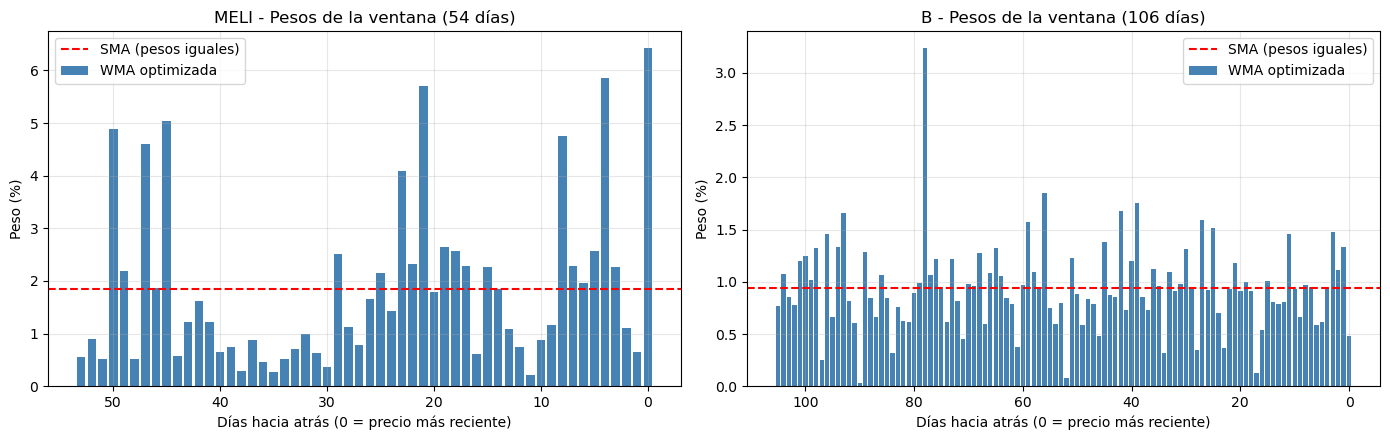

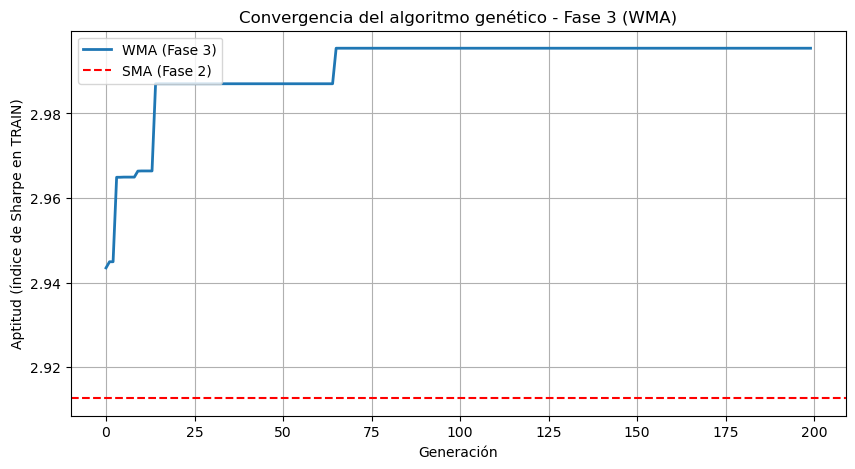

In [28]:
fig, ejes = plt.subplots(1, len(activos_opt), figsize=(14, 4.5))
ejes = np.atleast_1d(ejes)

for eje, i in zip(ejes, activos_opt):
    w = bloques_optimos[i]
    n = len(w)
    dias_atras = np.arange(n - 1, -1, -1)   # w[-1] corresponde al precio más reciente

    eje.bar(dias_atras, w * 100, color="steelblue", label="WMA optimizada")
    eje.axhline(100 / n, color="red", linestyle="--", label="SMA (pesos iguales)")
    eje.set_title(f"{tickers[i]} - Pesos de la ventana ({n} días)")
    eje.set_xlabel("Días hacia atrás (0 = precio más reciente)")
    eje.set_ylabel("Peso (%)")
    eje.invert_xaxis()
    eje.grid(True, alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_f3, linewidth=2, label="WMA (Fase 3)")
plt.axhline(sharpe_optimo, color="red", linestyle="--", label="SMA (Fase 2)")
plt.title("Convergencia del algoritmo genético - Fase 3 (WMA)")
plt.xlabel("Generación")
plt.ylabel("Aptitud (índice de Sharpe en TRAIN)")
plt.legend()
plt.grid(True)
plt.show()

<a id="f3-test"></a>
### 6.7 Validación fuera de muestra: SMA frente a WMA

Además de la SMA de la Fase 2, se incluye como referencia la WMA lineal clásica (pesos proporcionales a $1, 2, \dots, n$) sin optimizar, para medir cuánto aporta realmente el algoritmo genético.

In [29]:
bloques_lineales = [reparar_pesos(np.arange(1, n + 1)) for n in longitudes]

# Serie completa (TRAIN y TEST) para que la media móvil tenga historial al iniciar la prueba
retornos_completos_wma = calcular_rendimiento_wma(prices, pesos_optimos, bloques_optimos)
retornos_completos_lin = calcular_rendimiento_wma(prices, pesos_optimos, bloques_lineales)

retornos_test_wma = retornos_completos_wma.loc[test_start:test_end]
retornos_test_lin = retornos_completos_lin.loc[test_start:test_end]
retornos_train_lin = retornos_completos_lin.loc[train_start:train_end]

estrategias = {
    "Fase 2 - SMA": (retornos_optimos, retornos_test_f2),
    "Fase 3 - WMA lineal (sin optimizar)": (retornos_train_lin, retornos_test_lin),
    "Fase 3 - WMA optimizada (AG)": (retornos_wma, retornos_test_wma),
}

filas = []
for nombre, (r_train, r_test) in estrategias.items():
    for periodo, r in (("TRAIN", r_train), ("TEST", r_test)):
        m = metricas(r)
        filas.append({
            "Estrategia": nombre,
            "Periodo": periodo,
            "Rend. anualizado": f"{m['Rendimiento anual'] * 100:.2f}%",
            "Riesgo anualizado": f"{m['Volatilidad'] * 100:.2f}%",
            "Índice de Sharpe": f"{m['Sharpe']:.4f}",
            "Máxima caída": f"{m['Max Drawdown'] * 100:.2f}%",
            "Capital final": f"${capital * (1 + r).prod():,.2f}",
        })

comparacion_f3 = pd.DataFrame(filas)
display(comparacion_f3)

,Estrategia,Periodo,Rend. anualizado,Riesgo anualizado,Índice de Sharpe,Máxima caída,Capital final
0,Fase 2 - SMA,TRAIN,45.45%,14.37%,2.9127,-4.00%,"$1,553,358.80"
1,Fase 2 - SMA,TEST,29.84%,33.87%,0.7748,-29.60%,"$1,272,164.07"
2,Fase 3 - WMA lineal (sin optimizar),TRAIN,39.69%,18.05%,1.9989,-8.04%,"$1,458,504.74"
3,Fase 3 - WMA lineal (sin optimizar),TEST,25.91%,34.00%,0.6563,-30.95%,"$1,222,509.03"
4,Fase 3 - WMA optimizada (AG),TRAIN,46.74%,14.40%,2.9954,-4.00%,"$1,573,249.01"
5,Fase 3 - WMA optimizada (AG),TEST,30.70%,33.88%,0.8001,-28.19%,"$1,283,129.55"


<a id="f3-comisiones"></a>
### 6.8 Efecto de las comisiones

Una WMA con pesos irregulares podría cruzar el precio con mayor frecuencia que una SMA y, por lo tanto, pagar más comisiones. Siguiendo el supuesto del script de apoyo de la materia (`trading_MediaMovil.py`), se repite la simulación en TEST con una comisión de 0.25% por operación, aplicada como aproximación sobre el capital asignado a cada activo.

In [30]:
COMISION = 0.0025


def calcular_rendimiento_wma_neto(precios, pesos_capital, bloques, comision=COMISION):
    """
    Rendimientos diarios del portafolio descontando la comisión.

    Cada compra o venta cuesta 'comision' sobre el capital asignado al activo
    (aproximación: el valor de la posición es cercano a su capital inicial).
    Devuelve los rendimientos netos y las operaciones diarias de cada activo.
    """
    retornos = pd.Series(0.0, index=precios.index)
    operaciones = pd.DataFrame(0.0, index=precios.index, columns=tickers)

    for i, ticker in enumerate(tickers):
        posicion = calcular_posiciones_wma(precios[ticker], bloques[i]).shift(1).fillna(0)
        bruto = posicion * precios[ticker].pct_change().fillna(0)
        cambios = posicion.diff().abs().fillna(posicion.abs())

        retornos += (bruto - comision * cambios) * pesos_capital[i]
        operaciones[ticker] = cambios

    return retornos, operaciones


# La SMA equivale a una WMA con pesos iguales, por lo que se evalúa con la misma función
bloques_sma = [np.full(n, 1.0 / n) for n in longitudes]

configuraciones = {
    "Fase 2 - SMA": bloques_sma,
    "Fase 3 - WMA lineal (sin optimizar)": bloques_lineales,
    "Fase 3 - WMA optimizada (AG)": bloques_optimos,
}

filas = []
for nombre, bloques in configuraciones.items():
    r_bruto = calcular_rendimiento_wma(prices, pesos_optimos, bloques).loc[test_start:test_end]
    r_neto, ops = calcular_rendimiento_wma_neto(prices, pesos_optimos, bloques)
    r_neto = r_neto.loc[test_start:test_end]
    ops = ops.loc[test_start:test_end]

    filas.append({
        "Estrategia": nombre,
        "Operaciones en TEST": int(ops[[tickers[i] for i in activos_opt]].sum().sum()),
        "Sharpe sin comisión": f"{metricas(r_bruto)['Sharpe']:.4f}",
        "Sharpe con comisión": f"{metricas(r_neto)['Sharpe']:.4f}",
        "Capital final sin comisión": f"${capital * (1 + r_bruto).prod():,.2f}",
        "Capital final con comisión": f"${capital * (1 + r_neto).prod():,.2f}",
    })

comparacion_comision = pd.DataFrame(filas)
print(f"Comisión por operación: {COMISION * 100:.2f}%\n")
display(comparacion_comision)

# Comprobación: la SMA evaluada con las funciones de la Fase 3 reproduce la Fase 2
r_sma_check = calcular_rendimiento_wma(prices, pesos_optimos, bloques_sma).loc[test_start:test_end]
print("La WMA con pesos iguales reproduce la SMA de la Fase 2:", np.allclose(r_sma_check, retornos_test_f2))

Comisión por operación: 0.25%



,Estrategia,Operaciones en TEST,Sharpe sin comisión,Sharpe con comisión,Capital final sin comisión,Capital final con comisión
0,Fase 2 - SMA,26,0.7748,0.7149,"$1,272,164.07","$1,246,778.11"
1,Fase 3 - WMA lineal (sin optimizar),32,0.6563,0.5681,"$1,222,509.03","$1,186,721.96"
2,Fase 3 - WMA optimizada (AG),22,0.8001,0.7553,"$1,283,129.55","$1,263,881.16"


La WMA con pesos iguales reproduce la SMA de la Fase 2: True


<a id="f3-discusion"></a>
### 6.9 Discusión de la Fase 3

**Pesos óptimos.** El algoritmo genético encontró pesos válidos (no negativos y con suma de 100.0000000000%) para las ventanas de MELI (54 días) y B (106 días), con un cromosoma de 160 genes. REGN recibió un capital prácticamente nulo en la Fase 2, por lo que conserva la SMA. Los pesos no siguen un patrón suave. En MELI hay una inclinación hacia los precios recientes: el último 20% de la ventana concentra 29.07% del peso (frente al 20% de una SMA) y el precio más reciente recibe el mayor peso (6.43%, frente a 1.85% en la SMA); sin embargo, también aparecen picos aislados en precios de hace 45 a 50 días. En B no se observa esa inclinación: el último 20% de la ventana concentra 18.40% del peso y el mayor peso (3.24%) corresponde a un precio de hace casi 80 días.

**Desempeño en TRAIN.** La WMA optimizada mejora a la SMA (índice de Sharpe de 2.9954 frente a 2.9127; capital final de $1,573,249 frente a $1,553,359). La mejora era previsible, porque la SMA forma parte de la población inicial y el elitismo impide empeorar. La curva de convergencia muestra que desde la generación 0 un individuo aleatorio ya superaba a la SMA, que el algoritmo siguió mejorando hasta cerca de la generación 65 y que la aptitud no cambió durante el resto de las generaciones.

**Desempeño en TEST.** La mejora se sostiene fuera de muestra, aunque de forma moderada: el índice de Sharpe es de 0.8001 frente a 0.7748 de la SMA, el capital final es mayor en $10,965 (+0.86%) y la máxima caída es menor (−28.19% frente a −29.60%). La WMA lineal sin optimizar resulta inferior a ambas (índice de Sharpe de 0.6563; capital final de $1,222,509), por lo que la ventaja no proviene simplemente de dar más peso a los precios recientes. Con una sola ejecución del algoritmo y un único periodo de prueba, esta diferencia no es concluyente.

**Comisiones.** La WMA optimizada realiza 22 operaciones en TEST, frente a 26 de la SMA y 32 de la WMA lineal. Al operar menos, con una comisión de 0.25% por operación su ventaja aumenta: índice de Sharpe de 0.7553 frente a 0.7149 y capital final de $1,263,881 frente a $1,246,778 (+$17,103). El costo total de las comisiones es de $19,248 para la WMA optimizada, $25,386 para la SMA y $35,787 para la WMA lineal.

**Sobreajuste.** Se ajustan 160 parámetros libres con alrededor de 250 observaciones diarias. La forma irregular de los pesos, con picos aislados que no responden a una regla con sentido económico, sugiere que una parte de ellos captura ruido del periodo de entrenamiento. En esta ejecución, la degradación del índice de Sharpe entre TRAIN y TEST de la WMA (73%) es similar a la de la SMA (73%), por lo que la mayor flexibilidad no empeoró el desempeño fuera de muestra; aun así, conviene confirmar el resultado con varias semillas y periodos de prueba. Una alternativa con menos parámetros, como la media móvil exponencial (un solo parámetro de decaimiento), reduciría este riesgo.

[↑ Volver al índice](#indice)

<a id="comparativa"></a>
## 7. Comparativa y resultados destacados

<a id="comp-destacados"></a>
### 7.1 Tabla de resultados destacados

La tabla reúne las ponderaciones de inversión de ambos portafolios (Markowitz y trading) y la media móvil encontrada para cada acción.

In [31]:
resumen_final = pd.DataFrame({
    "Activo": tickers,
    "Fase 1 - Máximo Sharpe": weights_sharpe,
    "Fase 1 - Mínima Semivarianza": weights_semi,
    "Fases 2 y 3 - Capital": pesos_optimos,
    "Capital inicial (Fases 2 y 3)": pesos_optimos * capital,
    "Ventana (días)": ventanas_optimas,
    "Media móvil - Fase 2": "SMA (pesos iguales)",
    "Media móvil - Fase 3": [
        "WMA (pesos optimizados)" if i in activos_opt else "SMA (capital ≈ 0)"
        for i in range(len(tickers))
    ],
})

display(formatear_tabla(
    resumen_final,
    porcentaje=["Fase 1 - Máximo Sharpe", "Fase 1 - Mínima Semivarianza", "Fases 2 y 3 - Capital"],
    moneda=["Capital inicial (Fases 2 y 3)"]
))

,Activo,Fase 1 - Máximo Sharpe,Fase 1 - Mínima Semivarianza,Fases 2 y 3 - Capital,Capital inicial (Fases 2 y 3),Ventana (días),Media móvil - Fase 2,Media móvil - Fase 3
0,MELI,21.49%,29.75%,14.53%,"$145,298.87",54,SMA (pesos iguales),WMA (pesos optimizados)
1,REGN,0.00%,20.98%,0.00%,$0.03,162,SMA (pesos iguales),SMA (capital ≈ 0)
2,B,78.51%,49.28%,85.47%,"$854,701.10",106,SMA (pesos iguales),WMA (pesos optimizados)


<a id="comp-global"></a>
### 7.2 Comparativa global en el periodo de prueba

Todas las estrategias parten de una inversión inicial de $1,000,000 y se evalúan en el mismo periodo TEST de un año, sin comisiones.

In [32]:
filas = []
for _, fila in resultados.iterrows():
    filas.append({
        "Estrategia": f"Fase 1 - {fila['Estrategia']} (comprar y mantener)",
        "Rend. anualizado": fila["Rendimiento anual"],
        "Riesgo anualizado": fila["Volatilidad"],
        "Índice de Sharpe": fila["Sharpe"],
        "Máxima caída": fila["Max Drawdown"],
        "Capital final": fila["Capital final"],
    })

for nombre, r in (("Fase 2 - SMA", retornos_test_f2),
                  ("Fase 3 - WMA optimizada", retornos_test_wma)):
    m = metricas(r)
    filas.append({
        "Estrategia": nombre,
        "Rend. anualizado": m["Rendimiento anual"],
        "Riesgo anualizado": m["Volatilidad"],
        "Índice de Sharpe": m["Sharpe"],
        "Máxima caída": m["Max Drawdown"],
        "Capital final": capital * (1 + r).prod(),
    })

comparativa_global = pd.DataFrame(filas)
display(formatear_tabla(
    comparativa_global,
    porcentaje=["Rend. anualizado", "Riesgo anualizado", "Máxima caída"],
    moneda=["Capital final"],
    decimales=["Índice de Sharpe"]
))

,Estrategia,Rend. anualizado,Riesgo anualizado,Índice de Sharpe,Máxima caída,Capital final
0,Fase 1 - Máximo Sharpe (comprar y mantener),39.72%,40.41%,0.8939,-29.57%,"$1,370,756.49"
1,Fase 1 - Mínima Semivarianza (comprar y mantener),29.89%,30.16%,0.8718,-26.06%,"$1,288,485.48"
2,Fase 1 - Equiponderado (comprar y mantener),25.04%,26.46%,0.8103,-25.41%,"$1,240,507.14"
3,Fase 2 - SMA,29.84%,33.87%,0.7748,-29.60%,"$1,272,164.07"
4,Fase 3 - WMA optimizada,30.70%,33.88%,0.8001,-28.19%,"$1,283,129.55"


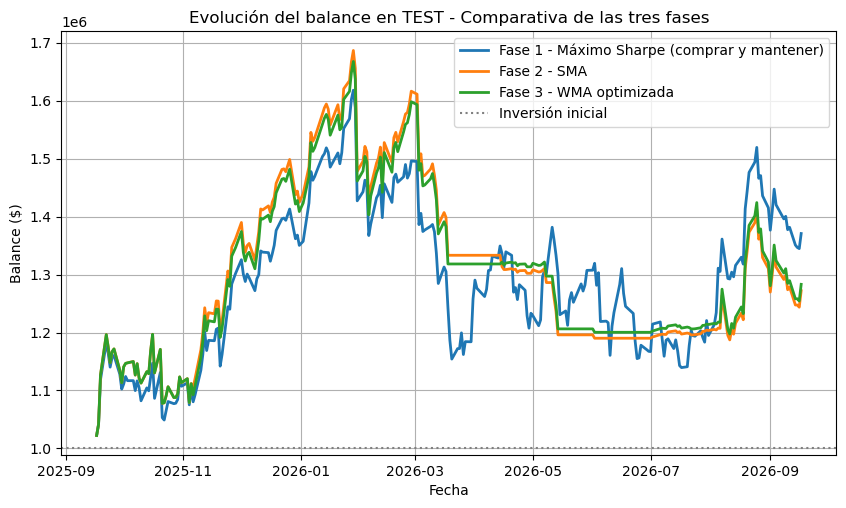

In [33]:
balance_f1 = capital * (1 + portfolio_test_returns["Máximo Sharpe"]).cumprod()
balance_f2 = capital * (1 + retornos_test_f2).cumprod()
balance_f3 = capital * (1 + retornos_test_wma).cumprod()

plt.figure(figsize=(10, 5.5))
plt.plot(balance_f1, linewidth=2, label="Fase 1 - Máximo Sharpe (comprar y mantener)")
plt.plot(balance_f2, linewidth=2, label="Fase 2 - SMA")
plt.plot(balance_f3, linewidth=2, label="Fase 3 - WMA optimizada")
plt.axhline(capital, color="gray", linestyle=":", label="Inversión inicial")
plt.title("Evolución del balance en TEST - Comparativa de las tres fases")
plt.xlabel("Fecha")
plt.ylabel("Balance ($)")
plt.legend()
plt.grid(True)
plt.show()

[↑ Volver al índice](#indice)

<a id="conclusiones"></a>
## 8. Conclusiones

1. **Fase 1.** El algoritmo genético encontró el portafolio de máximo Sharpe (MELI 21.49%, REGN 0.00%, B 78.51%; índice de Sharpe de 1.2246 en TRAIN) y el de mínima semivarianza con un rendimiento al menos igual al equiponderado (MELI 29.75%, REGN 20.98%, B 49.28%). En el periodo de prueba, el portafolio de máximo Sharpe fue la estrategia con mayor capital final ($1,370,756, es decir, +37.08%) y mayor índice de Sharpe (0.8939), a cambio de la mayor volatilidad (40.41%). El portafolio de mínima semivarianza cumplió su propósito: redujo la volatilidad a 30.16% y la máxima caída a −26.06% (frente a −29.57%), con un rendimiento acumulado de 28.85%.

2. **Fase 2.** Al optimizar conjuntamente el capital y las ventanas, el algoritmo concentró la inversión en B (85.47%, SMA de 106 días) y MELI (14.53%, SMA de 54 días), y excluyó a REGN. El índice de Sharpe cayó de 2.9127 en TRAIN a 0.7748 en TEST, con un capital final de $1,272,164.

3. **Fase 3.** La WMA optimizada cumplió la restricción de que los pesos sumen exactamente 100% y mejoró a la SMA tanto dentro como fuera de muestra (índice de Sharpe de 0.8001 y capital final de $1,283,130 en TEST). La ventaja aumenta al considerar comisiones, porque la WMA optimizada realiza menos operaciones. Se trata de una mejora moderada, obtenida con una sola ejecución y un único periodo de prueba, que debe confirmarse antes de considerarla una ventaja sistemática.

4. **Comparativa.** Ninguna estrategia de trading superó al portafolio de máximo Sharpe mantenido sin operar, ni en capital final ni en índice de Sharpe. El portafolio de mínima semivarianza (comprar y mantener) también terminó con más capital ($1,288,485 frente a $1,283,130 de la WMA y $1,272,164 de la SMA), con mayor índice de Sharpe (0.8718 frente a 0.8001 y 0.7748), menor volatilidad (30.16% frente a cerca de 33.9%) y menor máxima caída (−26.06% frente a −28.19% y −29.60%). La WMA optimizada tuvo un rendimiento anualizado ligeramente mayor (30.70% frente a 29.89%), pero su mayor volatilidad redujo su crecimiento acumulado. 

5. **Sobreajuste.** La degradación del índice de Sharpe entre TRAIN y TEST fue de 27% en la Fase 1 (3 parámetros) y de 73% en las fases 2 (6 parámetros) y 3 (160 parámetros). Los algoritmos genéticos resuelven con eficacia problemas no derivables y con restricciones, pero una mejor aptitud dentro de la muestra no garantiza un mejor desempeño fuera de ella. Además, en TRAIN cada media móvil necesita $n$ días de historial antes de generar señales, por lo que la estrategia permanece más tiempo en efectivo; esto reduce la volatilidad medida en TRAIN (14.37% frente a 33.87% en TEST) y hace que las métricas de ambos periodos no sean del todo comparables.

6. **Trabajo futuro.** Validar con varios periodos consecutivos (*walk-forward*), repetir cada algoritmo con distintas semillas para medir la variabilidad de los resultados, incluir las comisiones dentro de la función de aptitud y reducir el número de parámetros de la Fase 3 mediante una media móvil exponencial o una penalización a los pesos poco suaves.

[↑ Volver al índice](#indice)

<a id="bibliografia"></a>
## 9. Bibliografía

**Referencias teóricas**

- Bailey, D. H., Borwein, J. M., López de Prado, M. y Zhu, Q. J. (2014). Pseudo-mathematics and financial charlatanism: The effects of backtest overfitting on out-of-sample performance. *Notices of the American Mathematical Society, 61*(5), 458-471.
- Goldberg, D. E. (1989). *Genetic algorithms in search, optimization, and machine learning*. Addison-Wesley.
- Holland, J. H. (1975). *Adaptation in natural and artificial systems*. University of Michigan Press.
- Markowitz, H. (1952). Portfolio selection. *The Journal of Finance, 7*(1), 77-91.
- Murphy, J. J. (1999). *Technical analysis of the financial markets*. New York Institute of Finance.
- Sharpe, W. F. (1966). Mutual fund performance. *The Journal of Business, 39*(1), 119-138.
- Sortino, F. A. y van der Meer, R. (1991). Downside risk. *The Journal of Portfolio Management, 17*(4), 27-31.

**Material de apoyo de la materia**

- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *trading_MediaMovil.py* [Código fuente]. ITESO. Regla de trading con media móvil y supuesto de comisión de 0.25% por operación.
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *funPortafolio.py* [Código fuente]. ITESO. Cálculo del rendimiento esperado y del riesgo de un portafolio.
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *desv_esp_activos.py* [Código fuente]. ITESO. Frontera de Markowitz con tres activos.
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *downloadValues.py* [Código fuente]. ITESO. Descarga de precios históricos.

**Herramientas**

- Aroussi, R. (s. f.). *yfinance* [Software]. https://github.com/ranaroussi/yfinance
- Harris, C. R. et al. (2020). Array programming with NumPy. *Nature, 585*, 357-362.
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90-95.
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

[↑ Volver al índice](#indice)